# Booster Impact Tracker — Velocity Frame Edition (v2.1)

Run each cell with **Shift+Enter**.  
Change any parameter and re-run from that cell down (`Run → Run All Below`).

### Velocity-frame recap
| Symbol | Name | Description |
|--------|------|-------------|
| **γV** | Flight-path angle | Angle of velocity vector above horizontal (deg). Positive = climbing. |
| **γH** | Heading azimuth | Direction of horizontal velocity (deg). 0 = North, 90 = East. |
| **ê_t** | Tangential axis | Along velocity vector |
| **ê_nV** | Pitch-normal axis | ⊥ to velocity, upward in pitch plane — lift & pitch commands act here |
| **ê_nH** | Yaw-normal axis | Lateral direction — yaw commands act here |

### Changelog
| Version | Change |
|---------|--------|
| v2.1 | IACPN hit angle constraints (`hit_gamma_v`, `hit_gamma_h`, `hit_angle_range`); guidance active from launch (yaw-only during burn, full PN+IACPN post-burnout) |
| v2.0 | Velocity-frame formulation, gravity turn, lift, 3-D heading, PN guidance |

## 1 — Imports

In [1]:
from sim.simulate import simulate
from sim.physics import Params
from plot import plot_results
from dataclasses import replace
import matplotlib.pyplot as plt
%matplotlib inline
print('Imports OK')

Imports OK


## 2 — Parameters

> **Gravity turn tip:** use `launch_angle` ≥ 85° with `grav_turn=True`.  
> At 75° the rapid pitch-over at low speed keeps max altitude very low.  
> With `grav_turn=False` any angle works (thrust held at fixed body angle).

In [51]:
params = Params(
    # ── Booster ──────────────────────────────────────
    m_pay        = 50,     # kg  payload mass
    m_prop       = 495,    # kg  propellant mass
    m_str        = 50,     # kg  structural dry mass
    # ── Motor ────────────────────────────────────────
    isp          = 260,    # s
    thrust_kn    = 31,     # kN
    burn_max     = 20,     # s
    # ── Aerodynamics ─────────────────────────────────
    cd           = 0.4,    # drag coeff – powered
    cd_fall      = 1.2,    # drag coeff – tumbling post-burnout
    cl           = 0.0,    # lift coefficient  (0 = no lift)
    cd_ctrl      = 0.3,    # actuator drag (PN guidance)
    diam         = 0.5,    # m  reference diameter
    atm          = 'isa',  # 'isa' | 'exp' | 'none'
    # ── Launch angles ─────────────────────────────────
    launch_angle   = 60,   # deg  initial γV (elevation)
    launch_azimuth = 0,   # deg  aimed NE toward (10, 10) km target
    # ── Velocity-frame dynamics ───────────────────────
    grav_turn       = True,  # True → thrust ∥ velocity; False → fixed body angle
    grav_turn_v_min = 30.0,  # m/s  minimum speed before gravity turn activates
    a_cmd_t         = 0.0,   # m/s²  tangential accel command (ê_t)
    a_cmd_nv        = 0.0,   # m/s²  pitch-normal accel command (ê_nV)
    a_cmd_nh        = 0.0,   # m/s²  yaw-normal accel command (ê_nH)
    # ── PN/IACPN guidance target ──────────────────────
    x_target     = -14,     # km  North
    y_target     = 0,     # km  East
    z_target     = 0,      # km  altitude
    a_lat_max    = 20.0,    # g   lateral accel limit
    # ── Impact angle constraints (optional) ──────────
    hit_gamma_v     = None,  # deg  desired impact flight-path angle (e.g. -60); None = unconstrained
    hit_gamma_h     = None,  # deg  desired impact azimuth (e.g. 45); None = unconstrained
    hit_angle_range = None,  # km   range from target at which angle law activates; None = always
)

## 3 — Run simulation

In [52]:
result = simulate(params)

print('=== Summary ===')
for k, v in result['summary'].items():
    print(f'  {k:<30} {v}')

=== Summary ===
  max_altitude_km                7.21
  max_velocity_ms                807.9
  max_lift_kn                    0.0
  burnout_altitude_km            5.28
  burnout_time_s                 20.0
  burnout_gamma_v_deg            31.9
  impact_x_km                    17.92
  impact_y_km                    0.0
  impact_z_km                    -0.01
  impact_range_km                17.92
  miss_distance_m                31922.3
  flight_time_s                  93.8
  final_gamma_v_deg              -80.3
  final_gamma_h_deg              0.0


## 4 — Plots (7-panel dashboard)

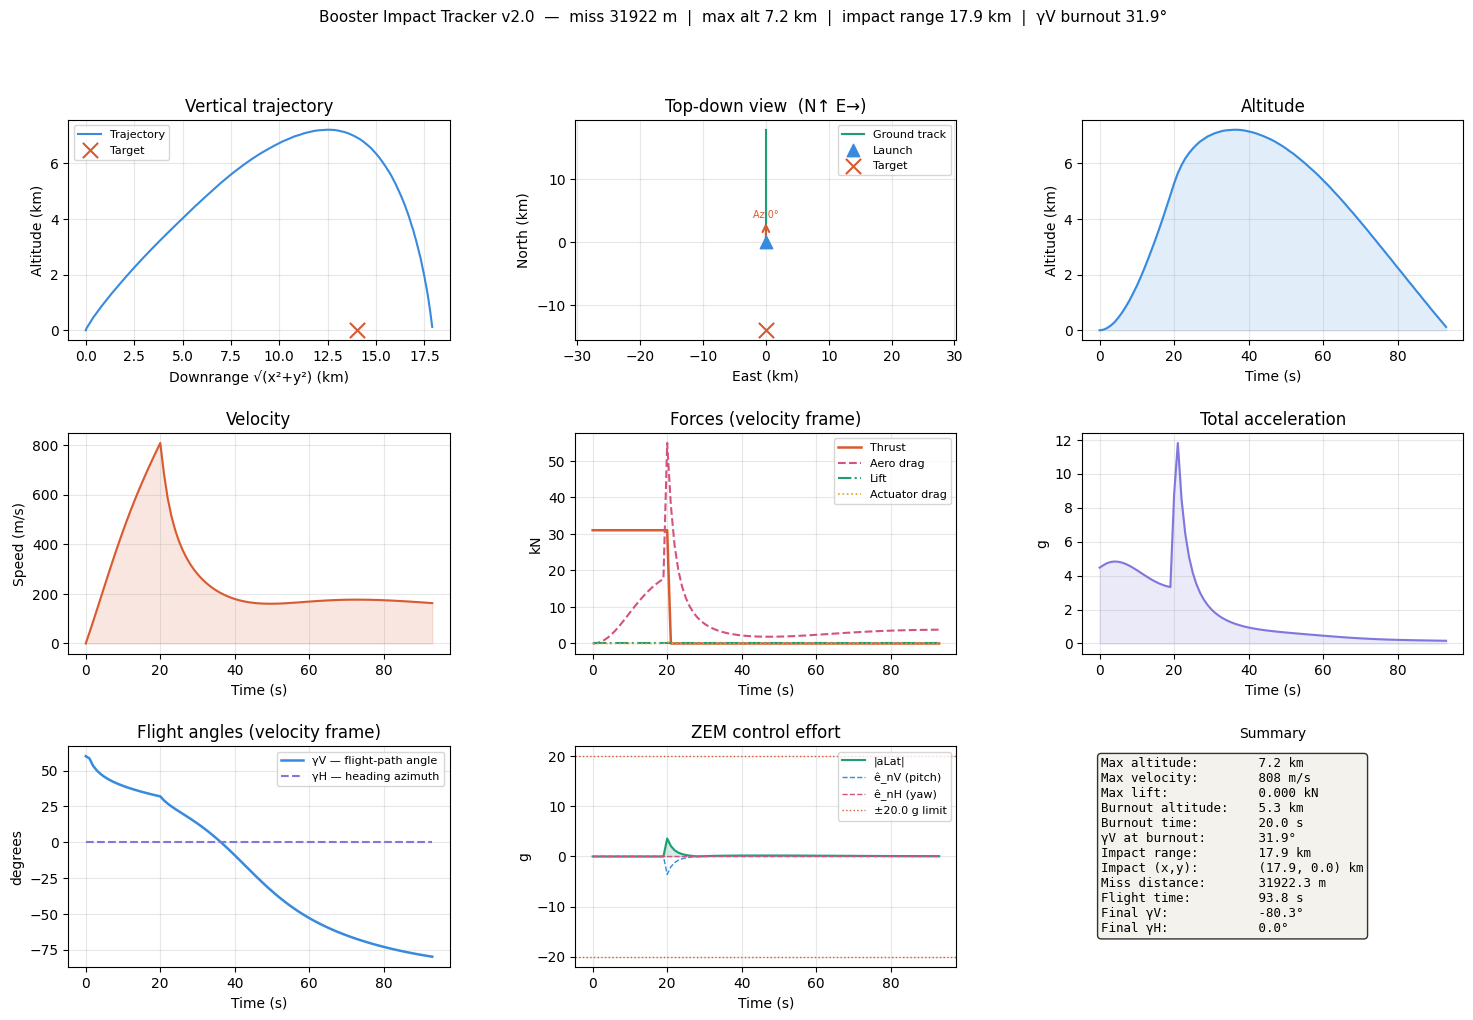

In [53]:
plot_results(result, params)

## 5 — Inspect time-series
All arrays live in `result['series']`.

In [9]:
s = result['series']
print('Available keys:', list(s.keys()))
print(f"Samples: {len(s['t'])}  |  Flight time: {s['t'][-1]} s")

Available keys: ['t', 'x', 'y', 'h', 'v', 'gamma_v', 'gamma_h', 'thr', 'drag_aero', 'lift', 'drag_ctrl', 'acc', 'aLat', 'a_nV', 'a_nH']
Samples: 48  |  Flight time: 47.0 s


In [10]:
i = 10   # <-- change to inspect any timestep

print(f"t = {s['t'][i]} s")
print(f"  Position :  h={s['h'][i]} km   x={s['x'][i]} km   y={s['y'][i]} km")
print(f"  Velocity :  v={s['v'][i]} m/s")
print(f"  Frame    :  γV={s['gamma_v'][i]}°   γH={s['gamma_h'][i]}°")
print(f"  Forces   :  thrust={s['thr'][i]} kN   drag={s['drag_aero'][i]} kN   lift={s['lift'][i]} kN")
print(f"  ZEM      :  |aLat|={s['aLat'][i]} g   (nV={s['a_nV'][i]} g, nH={s['a_nH'][i]} g)")
print(f"  Accel    :  {s['acc'][i]} g")

t = 10.0 s
  Position :  h=0.98 km   x=1.56 km   y=1.56 km
  Velocity :  v=471.1 m/s
  Frame    :  γV=18.65°   γH=45.0°
  Forces   :  thrust=31.0 kN   drag=9.71 kN   lift=0.0 kN
  ZEM      :  |aLat|=0.0 g   (nV=0.0 g, nH=0.0 g)
  Accel    :  4.394 g


## 6 — Flight-path angle profile (γV and γH)
Shows how the velocity-frame angles evolve over the full flight.

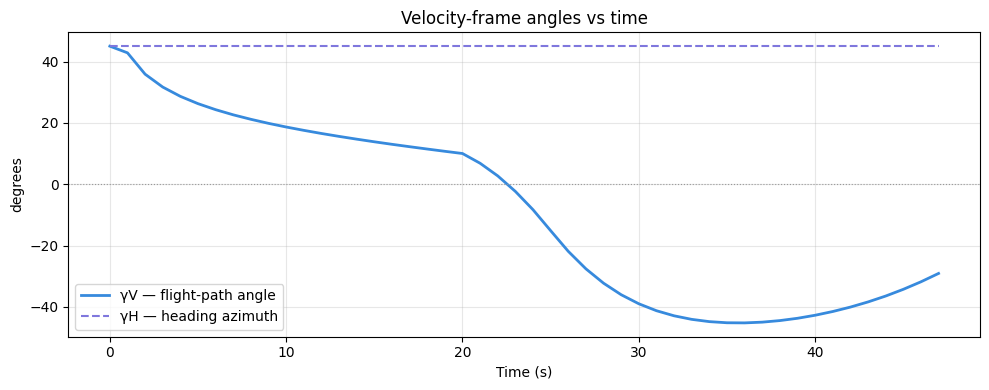

In [11]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(s['t'], s['gamma_v'], color='#378ADD', linewidth=2, label='γV — flight-path angle')
ax.plot(s['t'], s['gamma_h'], color='#7F77DD', linewidth=1.5, linestyle='--', label='γH — heading azimuth')
ax.axhline(0, color='#999', linewidth=0.8, linestyle=':')
ax.set_xlabel('Time (s)')
ax.set_ylabel('degrees')
ax.set_title('Velocity-frame angles vs time')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 7 — Gravity turn vs fixed-angle comparison
Runs the same vehicle twice and overlays the altitude and γV profiles.

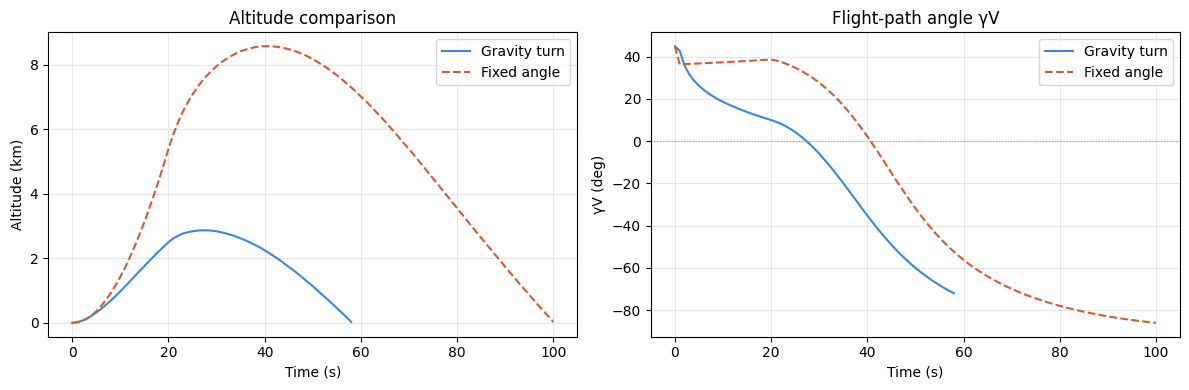

Gravity turn     max_alt=2.9 km  burnout_gV=10.0°  range=15.5 km
Fixed angle      max_alt=8.6 km  burnout_gV=38.7°  range=17.0 km


In [12]:
r_gt  = simulate(replace(params, grav_turn=True,  a_lat_max=0))  # no ZEM, pure ballistic
r_fix = simulate(replace(params, grav_turn=False, a_lat_max=0))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Altitude
ax1.plot(r_gt['series']['t'],  r_gt['series']['h'],  color='#378ADD', label='Gravity turn')
ax1.plot(r_fix['series']['t'], r_fix['series']['h'], color='#D85A30', linestyle='--', label='Fixed angle')
ax1.set_xlabel('Time (s)'); ax1.set_ylabel('Altitude (km)')
ax1.set_title('Altitude comparison'); ax1.legend(); ax1.grid(alpha=0.3)

# γV
ax2.plot(r_gt['series']['t'],  r_gt['series']['gamma_v'],  color='#378ADD', label='Gravity turn')
ax2.plot(r_fix['series']['t'], r_fix['series']['gamma_v'], color='#D85A30', linestyle='--', label='Fixed angle')
ax2.axhline(0, color='#999', linewidth=0.8, linestyle=':')
ax2.set_xlabel('Time (s)'); ax2.set_ylabel('γV (deg)')
ax2.set_title('Flight-path angle γV'); ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout(); plt.show()

for label, r in [('Gravity turn', r_gt), ('Fixed angle', r_fix)]:
    sm = r['summary']
    print(f"{label:<15}  max_alt={sm['max_altitude_km']:.1f} km  "
          f"burnout_gV={sm['burnout_gamma_v_deg']:.1f}°  "
          f"range={sm['impact_range_km']:.1f} km")

## 8 — Lift coefficient sweep
Shows how increasing CL slows the gravity-turn pitch-over (higher γV at burnout → more altitude).

   CL     max_alt    burnout_gV    max_lift       range
  0.0        2.87          10.0°       0.000 kN        15.5 km
  0.2        7.32          33.8°       9.922 kN        17.3 km
  0.5       13.62          66.3°      20.587 kN         7.5 km
  1.0       16.70          90.0°      35.796 kN         3.1 km


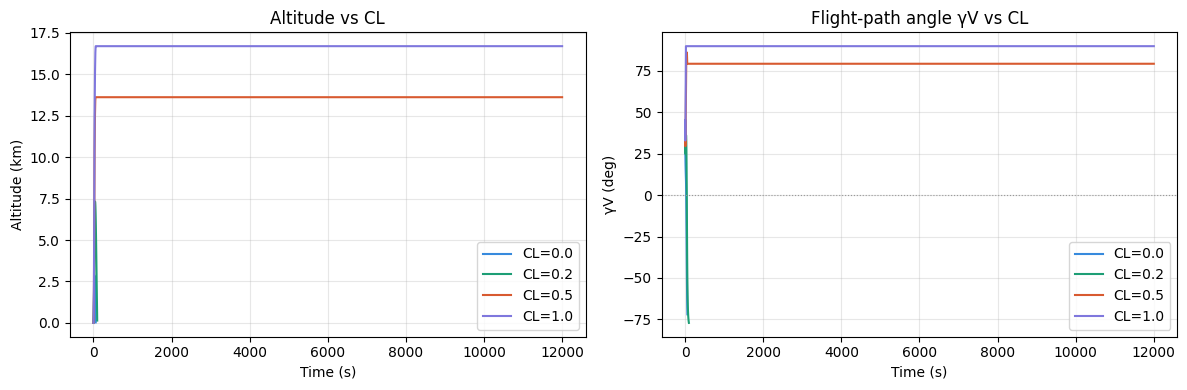

In [13]:
cl_values = [0.0, 0.2, 0.5, 1.0]
colors     = ['#378ADD', '#1D9E75', '#D85A30', '#7F77DD']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

print(f"{'CL':>5}  {'max_alt':>10}  {'burnout_gV':>12}  {'max_lift':>10}  {'range':>10}")
for cl, col in zip(cl_values, colors):
    r  = simulate(replace(params, cl=cl, a_lat_max=0))
    sm = r['summary']
    sv = r['series']
    ax1.plot(sv['t'], sv['h'],       color=col, label=f'CL={cl}')
    ax2.plot(sv['t'], sv['gamma_v'], color=col, label=f'CL={cl}')
    print(f"{cl:>5}  {sm['max_altitude_km']:>10.2f}  "
          f"{sm['burnout_gamma_v_deg']:>12.1f}°  "
          f"{sm['max_lift_kn']:>10.3f} kN  "
          f"{sm['impact_range_km']:>10.1f} km")

ax1.set_xlabel('Time (s)'); ax1.set_ylabel('Altitude (km)')
ax1.set_title('Altitude vs CL'); ax1.legend(); ax1.grid(alpha=0.3)
ax2.axhline(0, color='#999', linewidth=0.8, linestyle=':')
ax2.set_xlabel('Time (s)'); ax2.set_ylabel('γV (deg)')
ax2.set_title('Flight-path angle γV vs CL'); ax2.legend(); ax2.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 9 — Pitch acceleration command sweep (a_cmd_nv)
`a_cmd_nv` acts along **ê_nV** (pitch-normal). Positive pulls the flight path upward, slowing the gravity-turn pitch-over.

  a_nV     max_alt    burnout_gV       range
  -2.0        1.36           0.9°        13.8 km
  +0.0        2.87          10.0°        15.5 km
  +2.0        4.83          19.6°        17.4 km
  +5.0        8.84          34.7°        22.0 km


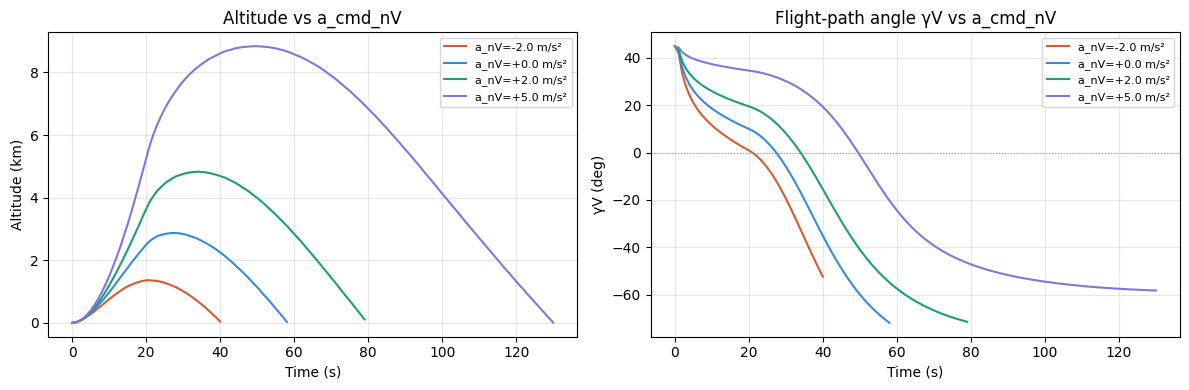

In [14]:
nv_values = [-2.0, 0.0, 2.0, 5.0]
colors     = ['#D85A30', '#378ADD', '#1D9E75', '#7F77DD']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

print(f"{'a_nV':>6}  {'max_alt':>10}  {'burnout_gV':>12}  {'range':>10}")
for nv, col in zip(nv_values, colors):
    r  = simulate(replace(params, a_cmd_nv=nv, a_lat_max=0))
    sm = r['summary']
    sv = r['series']
    ax1.plot(sv['t'], sv['h'],       color=col, label=f'a_nV={nv:+.1f} m/s²')
    ax2.plot(sv['t'], sv['gamma_v'], color=col, label=f'a_nV={nv:+.1f} m/s²')
    print(f"{nv:>+6.1f}  {sm['max_altitude_km']:>10.2f}  "
          f"{sm['burnout_gamma_v_deg']:>12.1f}°  "
          f"{sm['impact_range_km']:>10.1f} km")

ax1.set_xlabel('Time (s)'); ax1.set_ylabel('Altitude (km)')
ax1.set_title('Altitude vs a_cmd_nV'); ax1.legend(fontsize=8); ax1.grid(alpha=0.3)
ax2.axhline(0, color='#999', linewidth=0.8, linestyle=':')
ax2.set_xlabel('Time (s)'); ax2.set_ylabel('γV (deg)')
ax2.set_title('Flight-path angle γV vs a_cmd_nV'); ax2.legend(fontsize=8); ax2.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 10 — Yaw command sweep (a_cmd_nh)
`a_cmd_nh` acts along **ê_nH** (yaw-normal). It changes γH over time, diverting the booster laterally. The impact range uses 3-D distance √(x²+y²).

  a_nH    final_gH    impact_x    impact_y       range
  +0.0        45.0°       10.96 km       10.96 km        15.5 km
  +1.0        69.2°        9.76 km       12.00 km        15.5 km
  +3.0       117.5°        7.03 km       13.54 km        15.3 km
  -2.0        -3.3°       12.87 km        8.43 km        15.4 km


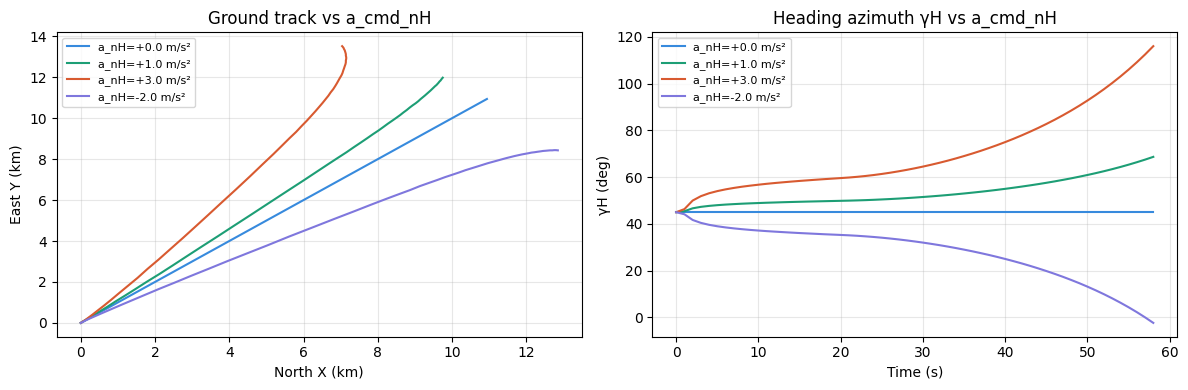

In [15]:
import math
nh_values = [0.0, 1.0, 3.0, -2.0]
colors     = ['#378ADD', '#1D9E75', '#D85A30', '#7F77DD']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

print(f"{'a_nH':>6}  {'final_gH':>10}  {'impact_x':>10}  {'impact_y':>10}  {'range':>10}")
for nh, col in zip(nh_values, colors):
    r  = simulate(replace(params, a_cmd_nh=nh, a_lat_max=0))
    sm = r['summary']
    sv = r['series']
    # Ground track
    ax1.plot(sv['x'], sv['y'], color=col, label=f'a_nH={nh:+.1f} m/s²')
    ax2.plot(sv['t'], sv['gamma_h'], color=col, label=f'a_nH={nh:+.1f} m/s²')
    print(f"{nh:>+6.1f}  {sm['final_gamma_h_deg']:>10.1f}°  "
          f"{sm['impact_x_km']:>10.2f} km  "
          f"{sm['impact_y_km']:>10.2f} km  "
          f"{sm['impact_range_km']:>10.1f} km")

ax1.set_xlabel('North X (km)'); ax1.set_ylabel('East Y (km)')
ax1.set_title('Ground track vs a_cmd_nH'); ax1.legend(fontsize=8); ax1.grid(alpha=0.3)
ax2.set_xlabel('Time (s)'); ax2.set_ylabel('γH (deg)')
ax2.set_title('Heading azimuth γH vs a_cmd_nH'); ax2.legend(fontsize=8); ax2.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 11 — Launch angle sweep
Classic trade: higher angle → more altitude, less range.

In [16]:
angles = [30, 45, 60, 75]

print(f"{'angle':>6}  {'max_alt':>10}  {'burnout_gV':>12}  {'burnout_alt':>12}  {'range':>10}  {'t_flight':>10}")
for angle in angles:
    r  = simulate(replace(params, launch_angle=angle, a_lat_max=0))
    sm = r['summary']
    print(f"{angle:>6}°  {sm['max_altitude_km']:>10.2f}  "
          f"{sm['burnout_gamma_v_deg']:>12.1f}°  "
          f"{sm['burnout_altitude_km']:>12.2f} km  "
          f"{sm['impact_range_km']:>10.1f} km  "
          f"{sm['flight_time_s']:>10.1f} s")

 angle     max_alt    burnout_gV   burnout_alt       range    t_flight
    30°        0.30          30.0°          0.00 km         8.0 km        18.6 s
    45°        2.87          10.0°          2.50 km        15.5 km        58.4 s
    60°        7.72          31.9°          5.28 km        17.1 km        94.0 s
    75°       14.29          59.0°          7.61 km        15.3 km       131.8 s


## 12 — Run check vectors (pytest)

In [17]:
!python -m pytest tests/check_vectors.py -v

============================= test session starts =============================
platform win32 -- Python 3.12.9, pytest-9.0.2, pluggy-1.6.0 -- c:\Users\Anastasia\AppData\Local\Programs\Python\Python312\python.exe
cachedir: .pytest_cache
rootdir: c:\Users\Anastasia\OneDrive\Desktop\Satellite_sim
plugins: anyio-4.13.0
collecting ... collected 14 items

tests/check_vectors.py::TestDeterminism::test_same_params_same_result PASSED [  7%]
tests/check_vectors.py::TestPhysicsInvariants::test_vertical_launch_zero_crossrange PASSED [ 14%]
tests/check_vectors.py::TestPhysicsInvariants::test_zero_propellant_stays_on_ground PASSED [ 21%]
tests/check_vectors.py::TestPhysicsInvariants::test_vacuum_zero_aero_drag PASSED [ 28%]
tests/check_vectors.py::TestPhysicsInvariants::test_altitude_non_negative PASSED [ 35%]
tests/check_vectors.py::TestPhysicsInvariants::test_burnout_altitude_below_max PASSED [ 42%]
tests/check_vectors.py::TestGuidance::test_guidance_reduces_miss PASSED  [ 50%]
tests/check_vector

## 13 — Impact angle constraints (IACPN)

Guidance is **active from launch**:
- **During burn** — yaw channel only (`a_nH`): heading is corrected toward the target while pitch is left to the gravity turn
- **After burnout** — full PN + IACPN on both pitch (`a_nV`) and yaw (`a_nH`) channels

Two optional terminal angle constraints can be added on top of PN:

| Parameter | Description |
|-----------|-------------|
| `hit_gamma_v` | Desired impact flight-path angle γV (deg). e.g. `−60` = 60° below horizontal; `−90` = vertical dive. `None` = unconstrained. |
| `hit_gamma_h` | Desired impact azimuth γH (deg). Same convention as `launch_azimuth`. `None` = unconstrained. |
| `hit_angle_range` | Range from target (km) at which the IACPN angle correction activates. Outside = pure PN; inside = IACPN. `None` = always active. |

When inside the activation range, the IACPN adds a tgo-weighted correction on top of PN:

```
a_nV_angle = K · v · sin(hit_γV − γV_LOS) / tgo
a_nH_angle = K · v · cos(γV) · sin(hit_γH − γH_LOS) / tgo
```

> **Note:** angle constraints trade miss distance for angle compliance.

In [18]:
from dataclasses import replace

base = Params(
    m_pay=50, m_prop=495, m_str=50, isp=260, thrust_kn=31, burn_max=20,
    cd=0.4, cd_fall=1.2, cl=0.0, cd_ctrl=0.3, diam=0.5,
    launch_angle=45, launch_azimuth=45,
    x_target=10, y_target=10, z_target=0, a_lat_max=3.0,
)

cases = [
    ('Pure PN (no angles)',         dict(hit_gamma_v=None, hit_gamma_h=None, hit_angle_range=None)),
    ('IACPN, range gate 15 km',    dict(hit_gamma_v=-60,  hit_gamma_h=45,   hit_angle_range=15)),
    ('IACPN, range gate  5 km',    dict(hit_gamma_v=-60,  hit_gamma_h=45,   hit_angle_range=5)),
    ('IACPN, always active',       dict(hit_gamma_v=-60,  hit_gamma_h=45,   hit_angle_range=None)),
    ('Vertical only (γV=-80)',      dict(hit_gamma_v=-80,  hit_gamma_h=None, hit_angle_range=15)),
]

print(f"{'Case':<30}  {'miss_m':>8}  {'γV_impact':>10}  {'γH_impact':>10}")
print('-' * 65)
for label, kw in cases:
    r = simulate(replace(base, **kw))
    sm = r['summary']
    print(f"{label:<30}  {sm['miss_distance_m']:>8.1f}  "
          f"{sm['final_gamma_v_deg']:>9.1f}°  "
          f"{sm['final_gamma_h_deg']:>9.1f}°")

Case                              miss_m   γV_impact   γH_impact
-----------------------------------------------------------------
Pure PN (no angles)                  0.9      -27.7°       45.0°
IACPN, range gate 15 km            856.3      -64.9°       45.0°
IACPN, range gate  5 km            856.3      -64.9°       45.0°
IACPN, always active               856.3      -64.9°       45.0°
Vertical only (γV=-80)            1479.4      -90.0°       45.0°


## 14 — IACPN angle constraint comparison
Guidance is active from launch. This section compares pure PN against IACPN with different angle constraints and range gates.

Case                              miss_m   γV_impact   γH_impact
-----------------------------------------------------------------
Pure PN                              0.9      -27.7°       45.0°
IACPN γV=-60 gate=15km             856.3      -64.9°       45.0°
IACPN γV=-60 gate=5km              856.3      -64.9°       45.0°
IACPN γV=-60 γH=45 gate=15         856.3      -64.9°       45.0°
IACPN γV=-80 always               1479.4      -90.0°       45.0°


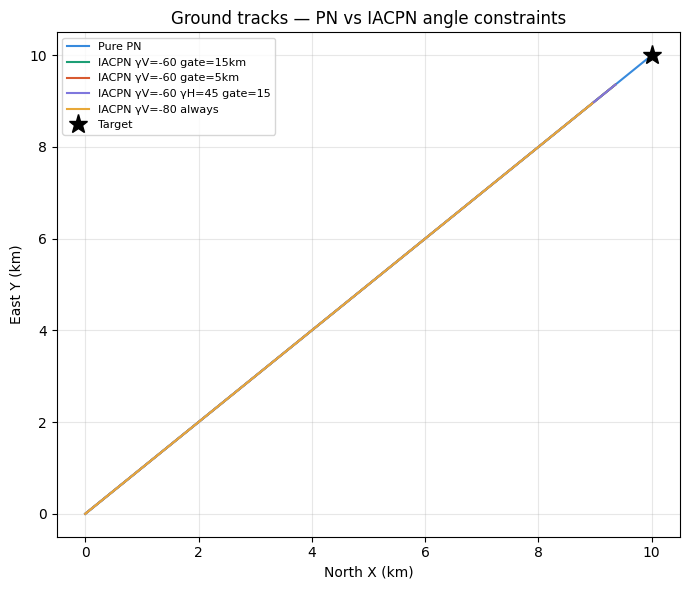

In [19]:
base = Params(
    m_pay=50, m_prop=495, m_str=50, isp=260, thrust_kn=31, burn_max=20,
    cd=0.4, cd_fall=1.2, cl=0.0, cd_ctrl=0.3, diam=0.5,
    launch_angle=45, launch_azimuth=45,
    x_target=10, y_target=10, z_target=0, a_lat_max=3.0,
)

cases = [
    ('Pure PN',                    dict(hit_gamma_v=None, hit_gamma_h=None, hit_angle_range=None)),
    ('IACPN γV=-60 gate=15km',    dict(hit_gamma_v=-60,  hit_gamma_h=None, hit_angle_range=15)),
    ('IACPN γV=-60 gate=5km',     dict(hit_gamma_v=-60,  hit_gamma_h=None, hit_angle_range=5)),
    ('IACPN γV=-60 γH=45 gate=15',dict(hit_gamma_v=-60,  hit_gamma_h=45,   hit_angle_range=15)),
    ('IACPN γV=-80 always',       dict(hit_gamma_v=-80,  hit_gamma_h=None, hit_angle_range=None)),
]

print(f"{'Case':<30}  {'miss_m':>8}  {'γV_impact':>10}  {'γH_impact':>10}")
print('-' * 65)
for label, kw in cases:
    r = simulate(replace(base, **kw))
    sm = r['summary']
    print(f"{label:<30}  {sm['miss_distance_m']:>8.1f}  "
          f"{sm['final_gamma_v_deg']:>9.1f}°  "
          f"{sm['final_gamma_h_deg']:>9.1f}°")

# ── Ground tracks ─────────────────────────────────────────────────────────────
colors = ['#378ADD', '#1D9E75', '#D85A30', '#7F77DD', '#E8A838']
fig, ax = plt.subplots(figsize=(7, 6))
for (label, kw), col in zip(cases, colors):
    r = simulate(replace(base, **kw))
    sv = r['series']
    ax.plot(sv['x'], sv['y'], color=col, label=label)
ax.plot(base.x_target, base.y_target, 'k*', markersize=14, label='Target')
ax.set_xlabel('North X (km)'); ax.set_ylabel('East Y (km)')
ax.set_title('Ground tracks — PN vs IACPN angle constraints')
ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 15 — Grid runner

`run_grid()` sweeps a **Cartesian product** of hit points × hit angles. All other parameters come from `base_params`.

```python
run_grid(base_params, hit_points, hit_angles=None, hit_angle_range=None)
```

| Argument | Type | Description |
|----------|------|-------------|
| `base_params` | `Params` | Shared parameters for all runs |
| `hit_points` | `[(x,y,z), ...]` km | Target locations to hit |
| `hit_angles` | `[(γV,γH), ...]` deg or `None` | Angle constraints — cross-product with hit_points. Either element may be `None`. Omit entirely for no constraints. |
| `hit_angle_range` | `float \| None` km | Range gate for angle law, applied to all constrained runs |

`plot_grid(runs)` shows a 4-panel dashboard: ground tracks, altitude profiles, γV profiles, miss distance bar chart + printed summary table.

Running 4 simulations...
  [SIM] Run 1/4:  target=(5,0,0) km  no angle
         miss=4390.3 m
  [SIM] Run 2/4:  target=(10,10,0) km  no angle
         miss=3030.9 m
  [SIM] Run 3/4:  target=(0,12,0) km  no angle
         miss=2124.5 m
  [SIM] Run 4/4:  target=(8,3,0) km  no angle
         miss=10.0 m


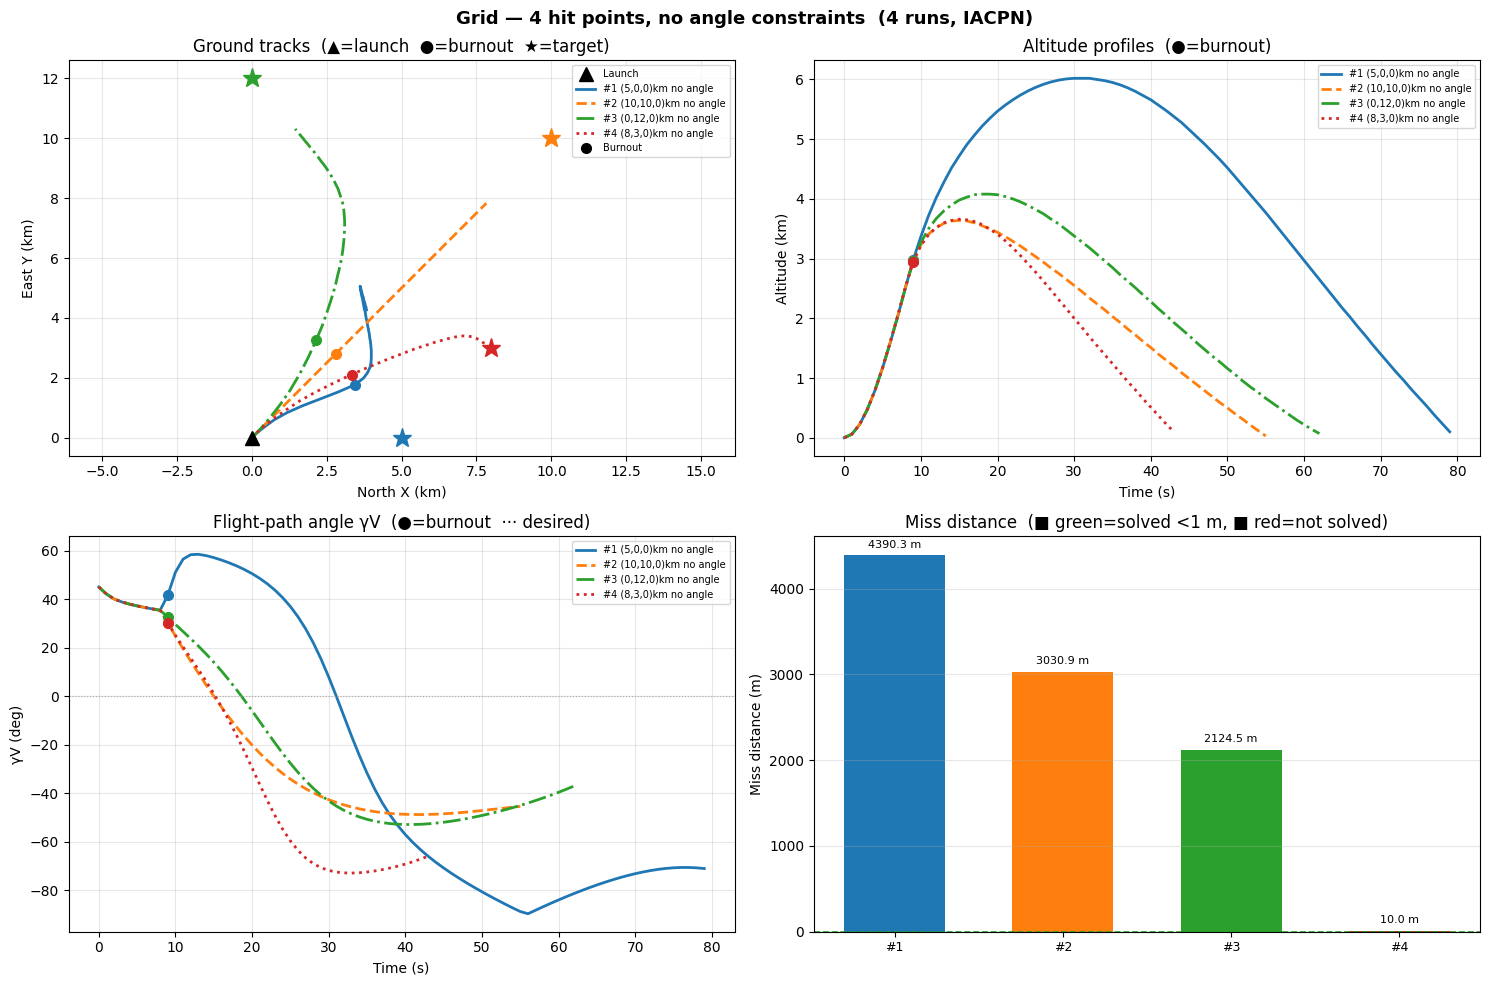


  #         Target (km)          Hit angles    miss_m    γV_imp    γH_imp   range_km
--------------------------------------------------------------------------------------
  1  (  5.0,  0.0, 0.0)           γV=— γH=—    4390.3    -71.4°    -74.7°       5.72
  2  ( 10.0, 10.0, 0.0)           γV=— γH=—    3030.9    -45.3°     45.0°      11.11
  3  (  0.0, 12.0, 0.0)           γV=— γH=—    2124.5    -35.7°    130.2°      10.48
  4  (  8.0,  3.0, 0.0)           γV=— γH=—      10.0    -66.1°    -33.3°       8.55


In [20]:
from grid_run import run_grid, plot_grid

base_grid = Params(
    m_pay=50, m_prop=100, m_str=50, isp=260, thrust_kn=31, burn_max=20,
    cd=0.4, cd_fall=0.4, cl=0.0, cd_ctrl=0.3, diam=0.5,
    launch_angle=45, launch_azimuth=45, a_lat_max=20.0,
)

# Hit points at very different ranges AND azimuths — maximally distinct paths
hit_points = [
    ( 5,  0, 0),   # close East   ~5 km
    (10, 10, 0),   # medium NE    ~14 km
    ( 0, 12, 0),   # medium North ~12 km
    ( 8,  3, 0),   # ESE          ~9 km
]

print(f'Running {len(hit_points)} simulations...')
runs1 = run_grid(base_grid, hit_points)
plot_grid(runs1, title='Grid — 4 hit points, no angle constraints')

  [SIM] Run 1/4:  target=(20,0,0) km  γV=-20° γH=None°
         miss=11077.4 m
  [SIM] Run 2/4:  target=(20,0,0) km  γV=-45° γH=None°
         miss=11077.4 m
  [SIM] Run 3/4:  target=(20,20,0) km  γV=-20° γH=None°
         miss=17511.8 m
  [SIM] Run 4/4:  target=(20,20,0) km  γV=-45° γH=None°
         miss=17511.8 m


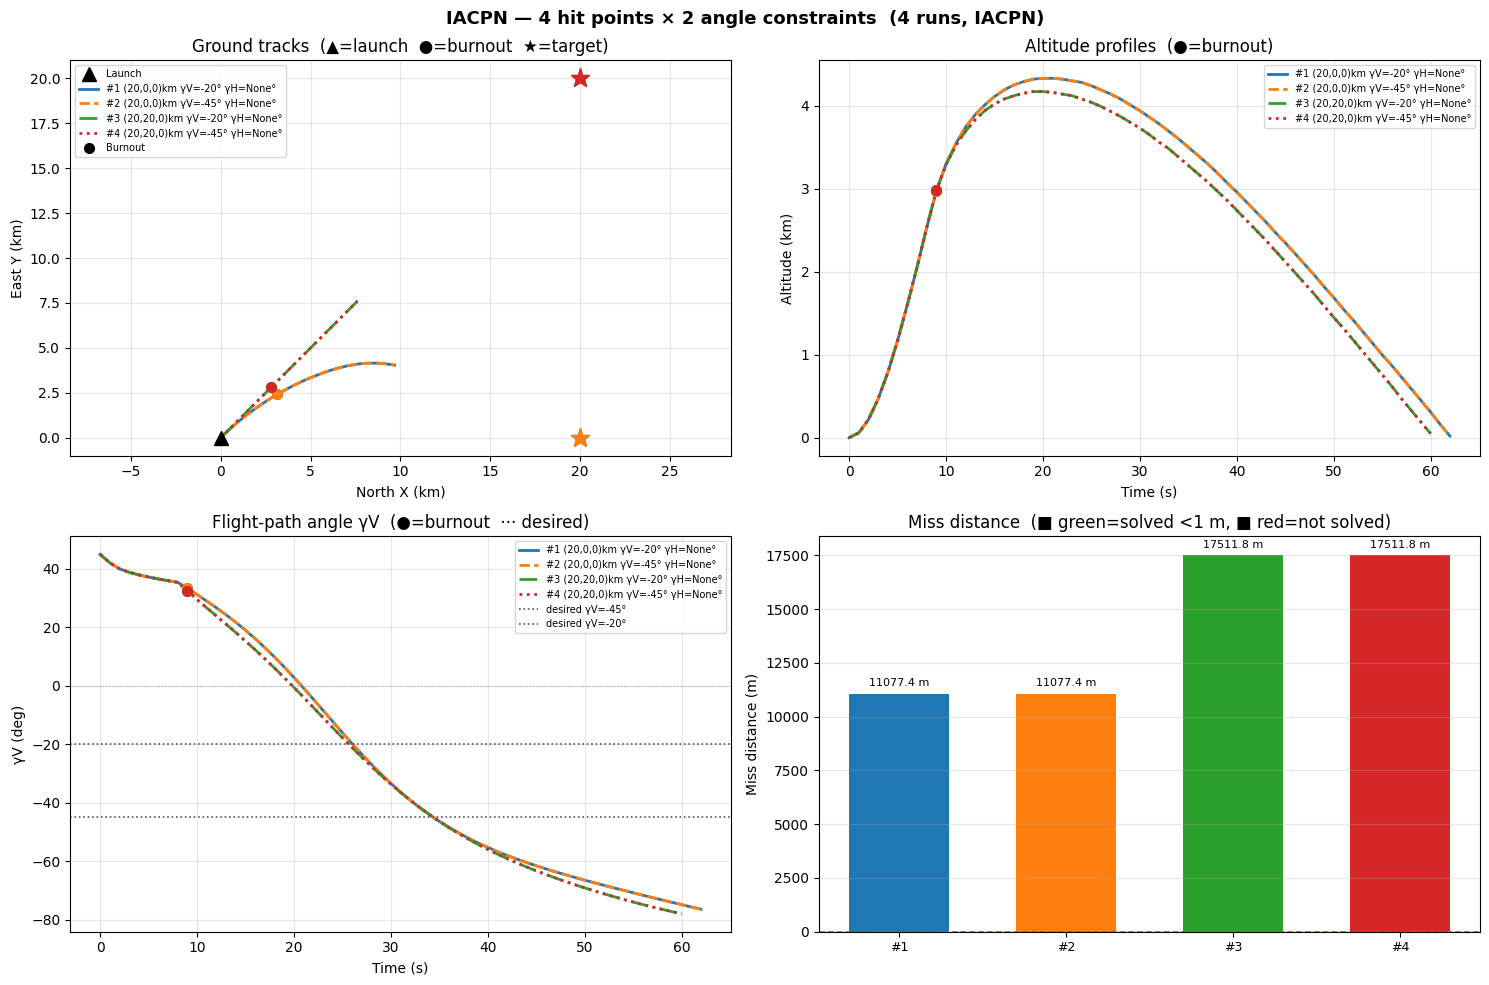


  #         Target (km)          Hit angles    miss_m    γV_imp    γH_imp   range_km
--------------------------------------------------------------------------------------
  1  ( 20.0,  0.0, 0.0)        γV=-20° γH=—   11077.4    -76.5°     -9.7°      10.49
  2  ( 20.0,  0.0, 0.0)        γV=-45° γH=—   11077.4    -76.5°     -9.7°      10.49
  3  ( 20.0, 20.0, 0.0)        γV=-20° γH=—   17511.8    -78.2°     45.0°      10.77
  4  ( 20.0, 20.0, 0.0)        γV=-45° γH=—   17511.8    -78.2°     45.0°      10.77


In [21]:
# Cross-product: 4 hit points × 2 angle constraints = 8 IACPN runs
hit_points2 = [
    ( 20,  0, 0),
    (20, 20, 0)
]
hit_angles2 = [(-20, None), (-45, None)]

runs2 = run_grid(base_grid, hit_points2, hit_angles=hit_angles2,
                 hit_angle_range=10)
plot_grid(runs2, title='IACPN — 4 hit points × 2 angle constraints')

## 16 — Open-loop trajectory optimisation

`optimize_trajectory()` finds the **optimal lateral acceleration schedule**
(a_nV(t), a_nH(t)) by minimising a merit function — no guidance law assumed.

**Merit function:**
    J = w_miss · miss²  +  w_angle_v · γV_err²  +  w_angle_h · γH_err²  +  w_time · t_f

**Two-phase strategy** (angle-constrained cases):
- Phase 1 — miss only: drives miss to < 1 m first.
- Phase 2 — full merit from Phase 1: improves angle accuracy
  while the large `w_miss` keeps miss small.

**Output key `solved`** = True when `optimised_miss_m < 1.0 m`.
**Output key `gamma_v_err_deg`** = actual impact angle − desired (active when `hit_gamma_v` set).

> **Physics note:** angle accuracy depends on trajectory energy.
> For a short-range flat trajectory (natural impact ~−10°), 3 g lateral
> can steer only a few degrees steeper. For steep angles (e.g. −60°)
> use a higher-arc trajectory (larger launch angle / longer range)
> or increase `a_max_g` / use `use_de=True`.

> **Performance:** The optimizer uses `_sim_eval_fast()` — an inlined, allocation-free
> simulation kernel that replaces per-step `State` dataclass creation and `np.interp`
> binary search with a direct bin-index formula.  This gives a **3.3× speedup**
> (≈70 s → ≈21 s for the 20-knot demo case) with bit-for-bit identical results.

In [22]:
from sim.opt_trajectory import optimize_trajectory, plot_optimised
from dataclasses import replace

# Basic case — miss-distance + flight-time minimisation
p_opt = Params(
    m_pay=10, m_prop=100, m_str=50, isp=260, thrust_kn=31, burn_max=20,
    cd=0.4, cd_fall=0.4, cl=0.0, cd_ctrl=0.3, diam=0.5,
    launch_angle=45, launch_azimuth=45,
    x_target=20, y_target=20, z_target=0, a_lat_max=20.0,
)

result_opt = optimize_trajectory(
    p_opt,
    n_knots=20,          # piecewise-linear knot points
    a_max_g=20.0,         # optimiser acceleration limit (g)
    w_miss=1.0,          # weight on miss^2 (per m^2)
    w_time=0.1,         # small nudge to minimise flight time
    method='L-BFGS-B',  # fast local solver
    max_iter=500,
    verbose=True,
)

print()
print('=== Optimisation summary ===')
for k, v in result_opt['summary'].items():
    print(f'  {k:<35} {v}')

  Nominal IACPN : miss = 19364.8 m,  t_f = 63.2 s
  Optimising 40 knot values,  a_max = 20.00 g,  method = L-BFGS-B,  dt_eval = 0.2 s
  Phase 1 — L-BFGS-B ...
  Phase 1 done : miss = 14827.66 m  |  3567 evals
  Total 3567 evaluations  |  best miss = 14827.66 m  |  t_f = 12000.0 s

=== Optimisation summary ===
  solved                              False
  nominal_miss_m                      19364.8
  optimised_miss_m                    14827.66
  nominal_flight_time_s               63.2
  optimised_flight_time_s             12000.0
  n_evaluations                       3567


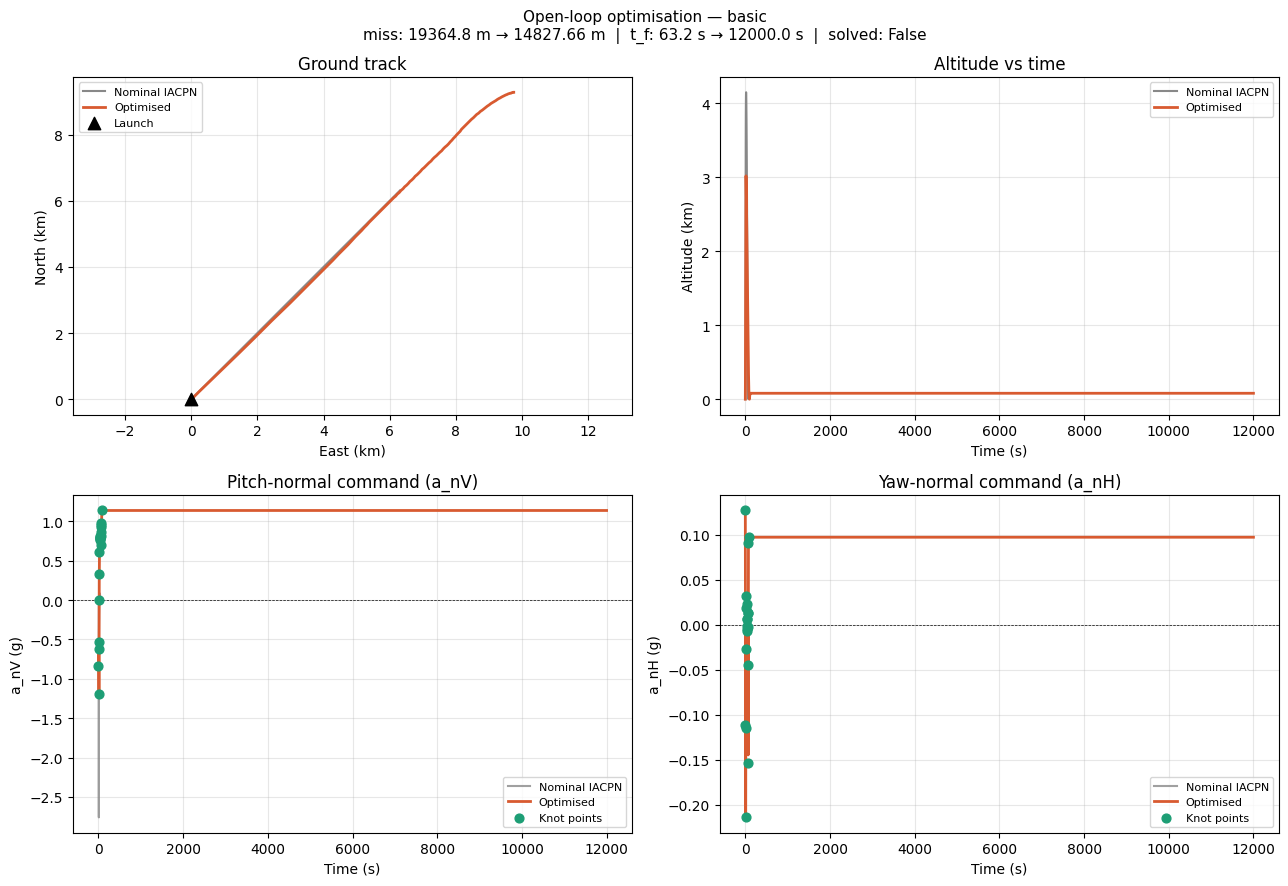

In [23]:
plot_optimised(result_opt, title='Open-loop optimisation — basic')

### 16b — With impact angle constraint

Two-phase optimisation runs automatically when `hit_gamma_v` / `hit_gamma_h` are set:
- Phase 1 guarantees `solved = True` (miss < 1 m).
- Phase 2 optimises angle accuracy from that starting point.

The achievable angle improvement depends on trajectory energy.
Check `gamma_v_err_deg` in the summary to see how close the
optimizer came to the desired impact angle.

In [ ]:
# With steep impact angle constraint  (hit_gamma_v = -70 deg)
# Two-phase optimisation runs automatically when angle constraints are set:
#   Phase 1 — miss only  → guarantees miss < 1 m
#   Phase 2 — full merit → improves angle accuracy from Phase 1 result
p_angle = replace(
    p_opt,
    hit_gamma_v=-30.0,     # desired impact flight-path angle (deg)
    hit_angle_range=None,  # angle correction active throughout
)

result_angle = optimize_trajectory(
    p_angle,
    n_knots=20,
    a_max_g=20.0,
    w_miss=1.0,
    w_angle_v=0.1,   # weight on gamma_V error^2 (per deg^2)
    w_time=0.1,
    verbose=True,
)

print()
print('=== Angle-constrained summary ===')
for k, v in result_angle['summary'].items():
    print(f'  {k:<35} {v}')

  Nominal IACPN : miss = 19581.6 m,  t_f = 60.2 s
  Warm-start    : no-angle IACPN, miss = 19364.8 m
  Optimising 40 knot values,  a_max = 20.00 g,  method = L-BFGS-B,  dt_eval = 0.2 s
  Phase 1 (miss only) — L-BFGS-B ...


In [ ]:
plot_optimised(result_angle, title='Open-loop optimisation — hit angle -70 deg')

## 17 — Optimizer grid run

`run_grid(..., optimise=True)` runs `optimize_trajectory()` for every
cell in the grid instead of the IACPN simulation.  The same
hit_points × hit_angles Cartesian product is used.

**Key differences from IACPN grid:**
- Each run uses the two-phase open-loop optimizer (miss-only → full merit).
- `solved = True` when `optimised_miss_m < 1 m`.
- `gamma_v_err_deg` / `gamma_h_err_deg` report angle accuracy.
- Bar chart: green = solved, red = not solved.
- `opt_kwargs` passes optimizer settings to every run
  (n_knots, a_max_g, w_angle_v, method, max_iter, use_de, …).

In [ ]:
# Optimizer grid — same hit points as Section 15, no angle constraint
# Demonstrates sub-metre miss for multiple targets simultaneously
opt_points = [
    (-15, 15, 0),
    ( 0, -15, 0),
]

runs_opt = run_grid(
    base_grid,
    opt_points,
    optimise=True,
    opt_kwargs=dict(
        n_knots=20,
        a_max_g=20.0,
        w_miss=1.0,
        w_time=1.0,
        max_iter=400,
    ),
)
plot_grid(runs_opt, title='Optimizer grid — 3 hit points, miss minimisation')

### 17b — Optimizer grid with angle constraints

Cross-product of hit_points × hit_angles, each cell fully optimised.

In [ ]:
# Optimizer grid with angle constraints
# Note: angle accuracy depends on trajectory energy for each target
opt_points_b = [
    (-20,-20, 0),
    ( 0, -20, 0),
]
opt_angles_b = [
    (-45, None),   # steep dive
    (None, None),  # no angle constraint
]

runs_opt_b = run_grid(
    base_grid,
    opt_points_b,
    hit_angles=opt_angles_b,
    optimise=True,
    opt_kwargs=dict(
        n_knots=20,
        a_max_g=3.0,
        w_miss=1.0,
        w_angle_v=0.01,
        w_time=1e-5,
        max_iter=400,
    ),
)
plot_grid(runs_opt_b, title='Optimizer grid — 2 points × 2 angle cases')